# Analysis of Periodic Calculations with ISDF

## Reference Calculations

* Ar
* LiF
* MoS2
* WSe took 140 s for one SCF step using 4 MPI processes, so not a sensible local test


In [3]:
%load_ext autoreload
%autoreload 2


In [4]:
from pathlib import Path

import parse_helper


In [5]:
"""Spread with Ar w.r.t. spacing (hence FFT cube grid) and k-sampling
"""

ar_root = Path("/Users/alexanderbuccheri/Codes/fresh_ocy/test_periodic_isdf_serial/4.Ar")
sub_dirs = [Path("222_0.5"), Path("222_0.25"), Path("333_0.5"), Path("333_0.25")]
profiles = {}
for dir in sub_dirs:
    label = dir.as_posix()
    profiles[label] = parse_helper.read_profiling_time(ar_root / dir)


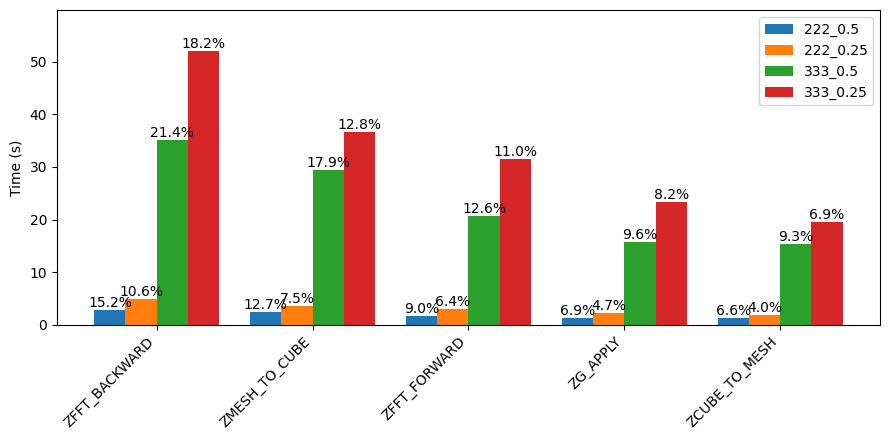

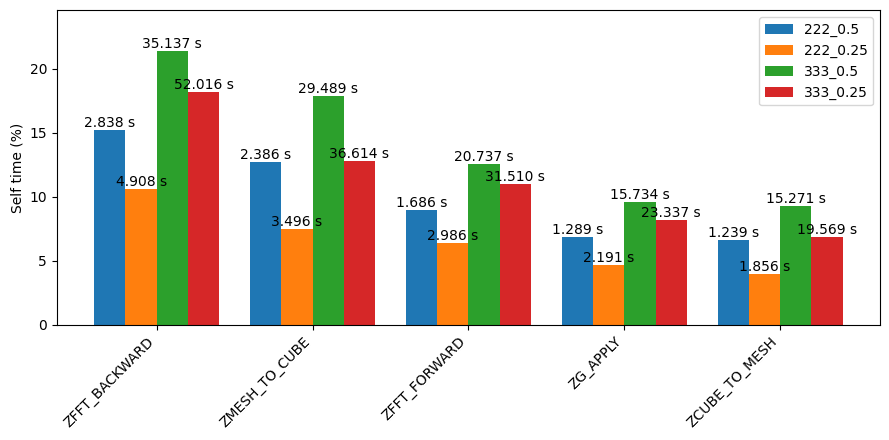

In [6]:
import matplotlib.pyplot as plt

from plot_helper import barplot_self_times

labels = [
    "ZFFT_BACKWARD",
    "ZMESH_TO_CUBE",
    "ZFFT_FORWARD",
    "ZG_APPLY",
    "ZCUBE_TO_MESH",
]

fig, ax = barplot_self_times(profiles, labels, y_axis="time")
plt.tight_layout()
plt.show()

fig, ax = barplot_self_times(profiles, labels, y_axis="percent")
plt.tight_layout()
plt.show()


Ar with k=(3, 3, 3) and FFT grid=(28, 28, 28)


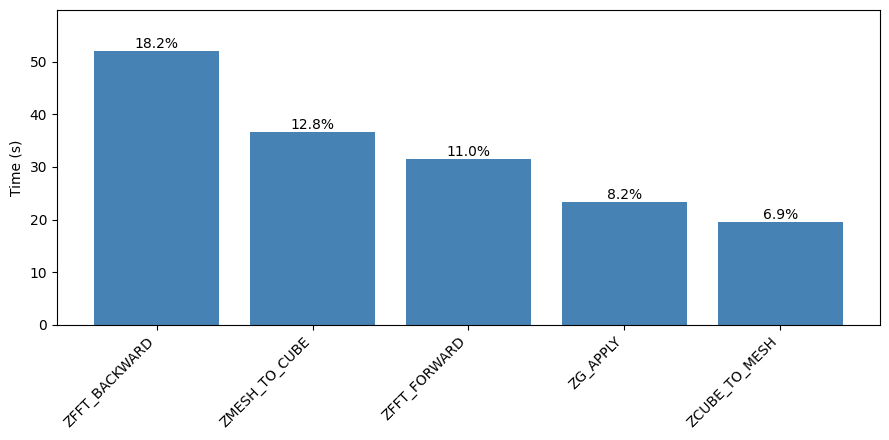

LiF with k=(2, 2, 2) and FFT grid=(?, ?, ?)


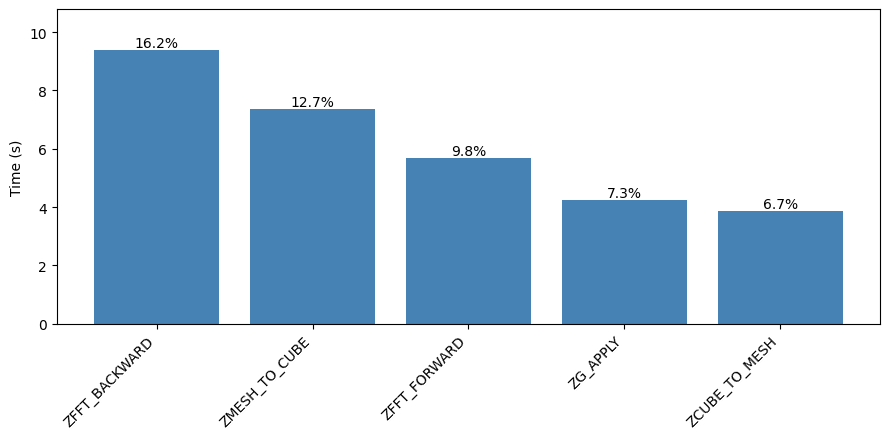

MoS2 with k=(2, 2, 1) and FFT grid=(13 x 13 x 52)


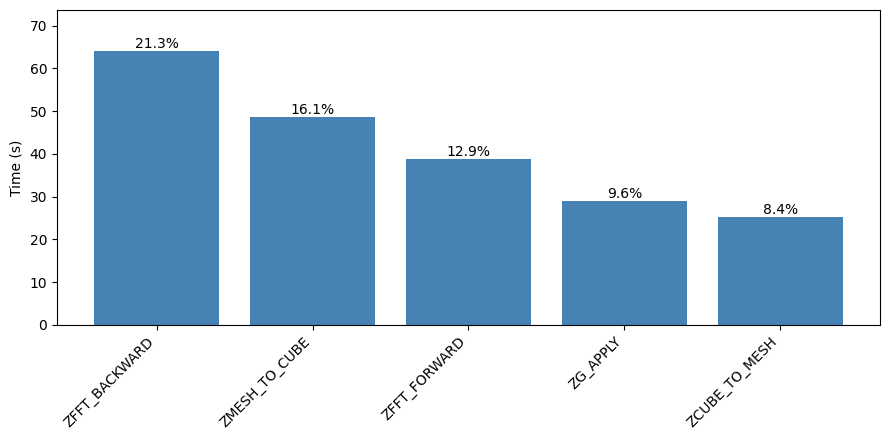

In [9]:
""" Self timings for each system running with a single MPI process
Benchmark on existing Implementation
"""
# Ar
ar_root = Path("/Users/alexanderbuccheri/Codes/fresh_ocy/test_periodic_isdf_serial/4.Ar")
ar_profiles = {"333_0.25": parse_helper.read_profiling_time(ar_root / Path("333_0.25"))}

print("Ar with k=(3, 3, 3) and FFT grid=(28, 28, 28)")
fig, ax = barplot_self_times(ar_profiles, labels, y_axis="time")
plt.tight_layout()
plt.show()

# LiF
lif_root = Path("/Users/alexanderbuccheri/Codes/fresh_ocy/test_periodic_isdf_serial/5.LiF")
lif_profiles = {"222_0.3": parse_helper.read_profiling_time(lif_root)}

print("LiF with k=(2, 2, 2) and FFT grid=(?, ?, ?)")
fig, ax = barplot_self_times(lif_profiles, labels, y_axis="time")
plt.tight_layout()
plt.show()

# MoS2
mos2_root = Path("/Users/alexanderbuccheri/Codes/fresh_ocy/test_periodic_isdf_serial/6.MoS2_2H_bulk")
mos2_profiles = {"221_0.45": parse_helper.read_profiling_time(mos2_root)}

print("MoS2 with k=(2, 2, 1) and FFT grid=(13 x 13 x 52)")
fig, ax = barplot_self_times(mos2_profiles, labels, y_axis="time")
plt.tight_layout()
plt.show()



Ar with k=(2, 2, 2) and FFT grid=(14, 14, 14)


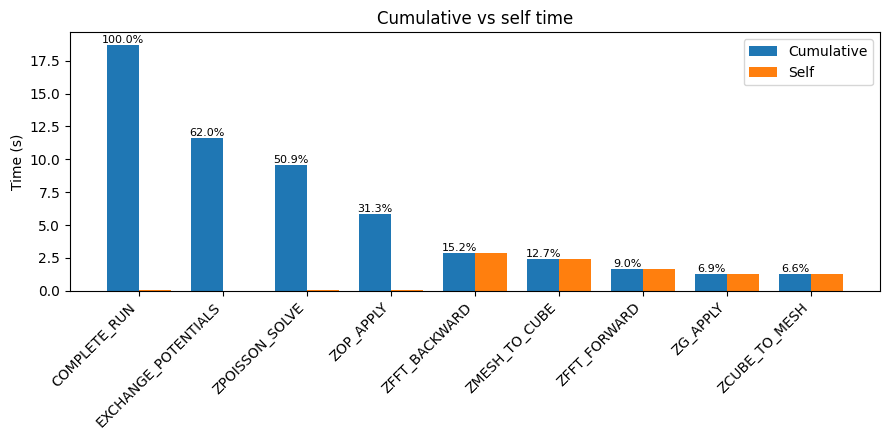

Ar with k=(3, 3, 3) and FFT grid=(14, 14, 14)


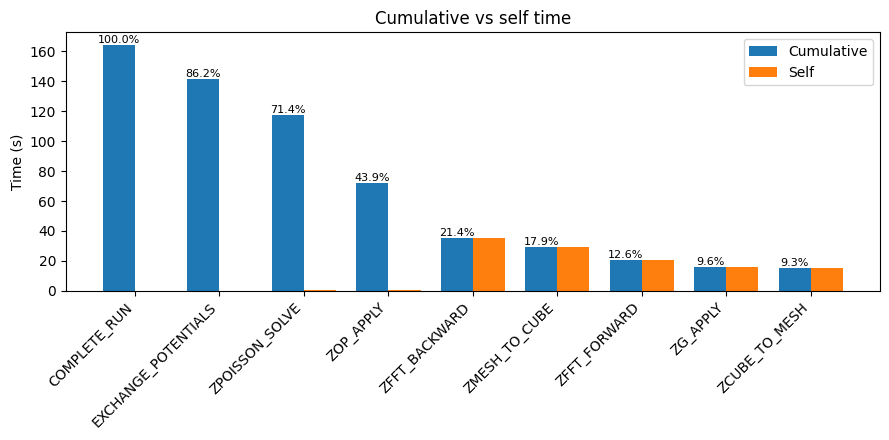

Ar with k=(3, 3, 3) and FFT grid=(28, 28, 28)


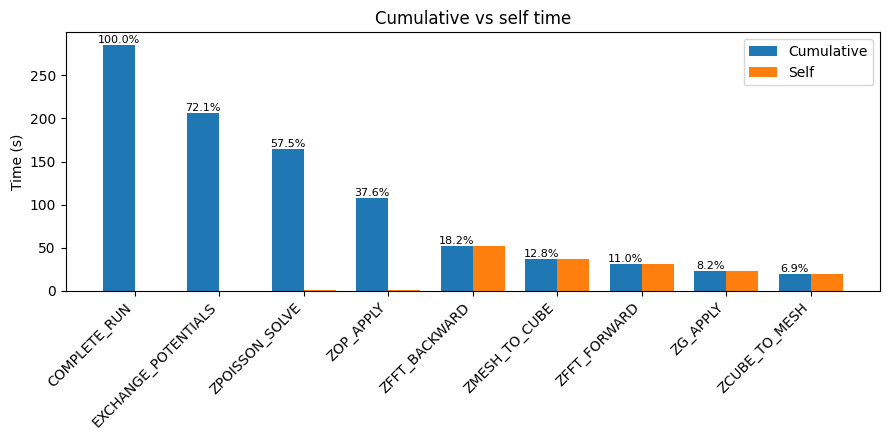

LiF with k=(2, 2, 2) and FFT grid=(?, ?, ?)


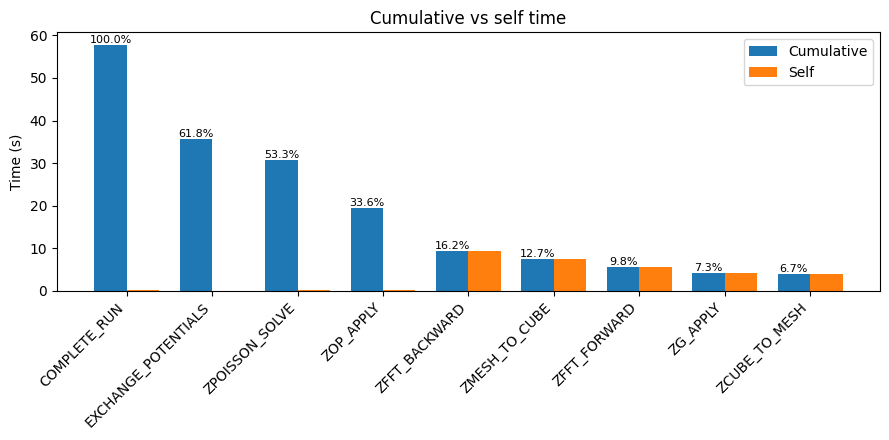

MoS2 with k=(2, 2, 1) and FFT grid=(13 x 13 x 52)


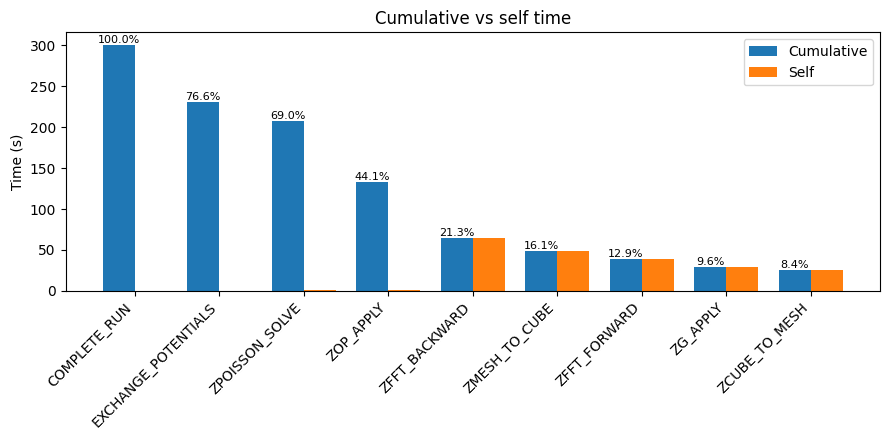

In [10]:
""" Cumulative Timings
"""
from plot_helper import cumulative_and_self

labels = [
    "COMPLETE_RUN",
    "ZPOISSON_SOLVE",
    "EXCHANGE_POTENTIALS",
    "ZOP_APPLY",
    "ZG_APPLY",
    "ZFFT_FORWARD",
    "ZFFT_BACKWARD",
    "ZMESH_TO_CUBE",
    "ZCUBE_TO_MESH",
]

print("Ar with k=(2, 2, 2) and FFT grid=(14, 14, 14)")
ar_profile = parse_helper.read_profiling_time(ar_root / Path("222_0.5"))
fig, ax = cumulative_and_self(ar_profile, labels)
plt.tight_layout()
plt.show()

print("Ar with k=(3, 3, 3) and FFT grid=(14, 14, 14)")
ar_profile = parse_helper.read_profiling_time(ar_root / Path("333_0.5"))
fig, ax = cumulative_and_self(ar_profile, labels)
plt.tight_layout()
plt.show()

print("Ar with k=(3, 3, 3) and FFT grid=(28, 28, 28)")
ar_profile = parse_helper.read_profiling_time(ar_root / Path("333_0.25"))
fig, ax = cumulative_and_self(ar_profile, labels)
plt.tight_layout()
plt.show()

print("LiF with k=(2, 2, 2) and FFT grid=(?, ?, ?)")
lif_profile = parse_helper.read_profiling_time(lif_root)
fig, ax = cumulative_and_self(lif_profile, labels)
plt.tight_layout()
plt.show()

print("MoS2 with k=(2, 2, 1) and FFT grid=(13 x 13 x 52)")
mos2_profile = parse_helper.read_profiling_time(mos2_root)
fig, ax = cumulative_and_self(mos2_profile, labels)
plt.tight_layout()
plt.show()